In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_diabetes
import warnings
warnings.filterwarnings("ignore")


In [5]:
dataset= load_diabetes()
dataset

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [6]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [7]:
dataset.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [8]:
df= pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [9]:
y= dataset.target
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [10]:
x_train, x_test, y_train, y_test= train_test_split(df, y, test_size=0.2, random_state=42)

<Axes: >

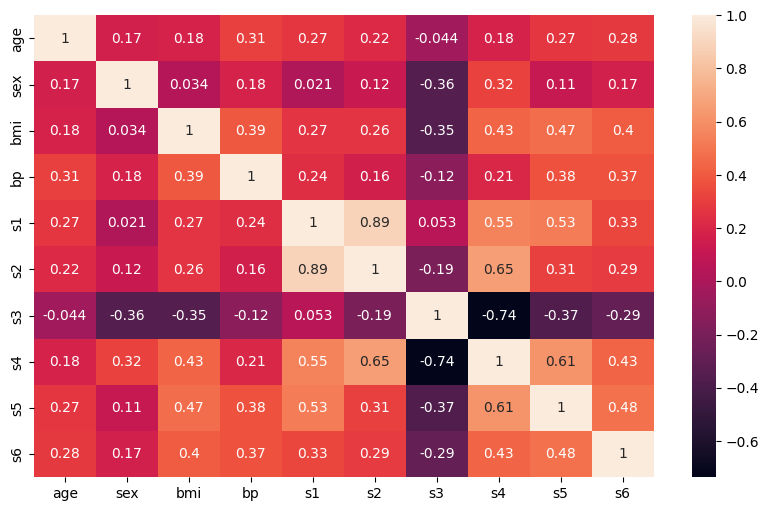

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(x_train.corr(), annot=True)

In [16]:
DG= DecisionTreeRegressor()
DG.fit(x_train, y_train)
y_pred= DG.predict(x_test)
from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 4957.662921348315
R2 Score: 0.06426558606284127


In [22]:
param_grid= {
    'criterion': ['mse', 'friedman_mse', 'mae'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 1,5,10,15,25,],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}
from sklearn.model_selection import GridSearchCV
grid_search= GridSearchCV(estimator=DG, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_DG= grid_search.best_estimator_
y_pred_best= best_DG.predict(x_test)
print("Mean Squared Error with Best Hyperparameters:", mean_squared_error(y_test, y_pred_best))
print("R2 Score with Best Hyperparameters:", r2_score(y_test, y_pred_best))


Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best Hyperparameters: {'criterion': 'friedman_mse', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}
Mean Squared Error with Best Hyperparameters: 3517.9753817021738
R2 Score with Best Hyperparameters: 0.33599950535823153


[Text(0.4674781976744186, 0.9642857142857143, 'x[3] <= -0.038\nfriedman_mse = 6076.398\nsamples = 353\nvalue = 153.737'),
 Text(0.10465116279069768, 0.8928571428571429, 'x[8] <= -0.061\nfriedman_mse = 3957.545\nsamples = 83\nvalue = 114.855'),
 Text(0.28606468023255816, 0.9285714285714286, 'True  '),
 Text(0.046511627906976744, 0.8214285714285714, 'x[6] <= 0.016\nfriedman_mse = 2104.264\nsamples = 11\nvalue = 77.909'),
 Text(0.023255813953488372, 0.75, 'friedman_mse = 2861.714\nsamples = 7\nvalue = 88.0'),
 Text(0.06976744186046512, 0.75, 'friedman_mse = 288.688\nsamples = 4\nvalue = 60.25'),
 Text(0.16279069767441862, 0.8214285714285714, 'x[6] <= -0.037\nfriedman_mse = 4000.278\nsamples = 72\nvalue = 120.5'),
 Text(0.11627906976744186, 0.75, 'x[1] <= 0.025\nfriedman_mse = 5436.934\nsamples = 16\nvalue = 157.062'),
 Text(0.09302325581395349, 0.6785714285714286, 'friedman_mse = 6661.109\nsamples = 8\nvalue = 199.125'),
 Text(0.13953488372093023, 0.6785714285714286, 'friedman_mse = 674.2

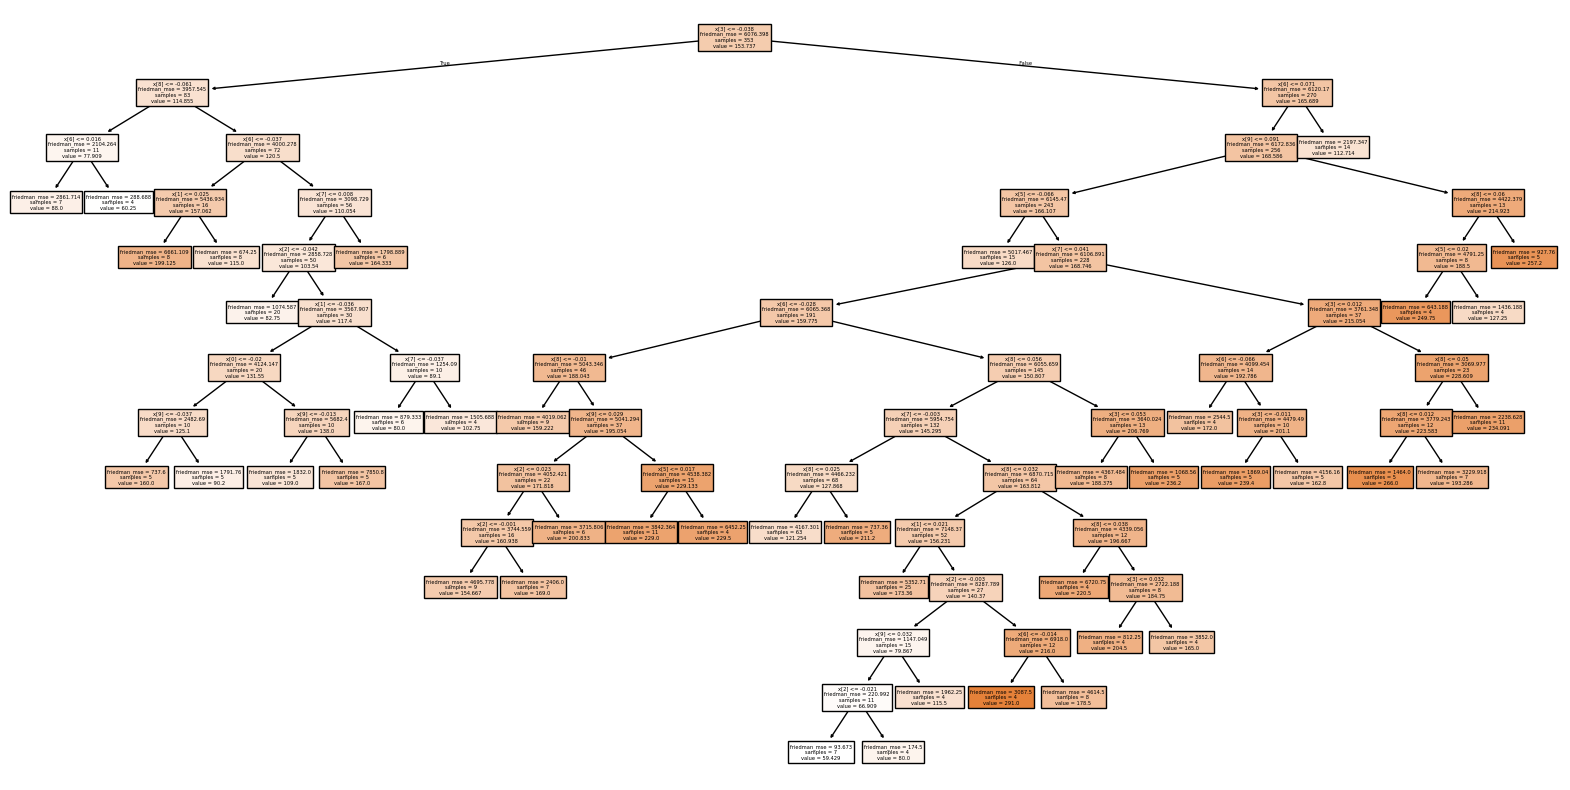

In [ ]:
from sklearn import tree
plt.figure(figsize=(20, 10))
tree.plot_tree(best_DG, filled=True)  
  
